In [12]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import Layout
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output, HTML

from ocp_formulation import setup_ocp
from car_model import make_car_integrator
from track_constraints import Pl_vis, Pu_vis, Pl_expr, Pu_expr
from utils import unpack_solution, plot_trajectory, warm_start_from_w

In [13]:
# Problem parameters
nx, nu = 7, 3
gear = 2  # selected gear for entire trajectory
dt = 0.1  # initial guess for time step
N = 20  # number of shooting intervals
B = 1.5
# Initial guess for final time T
T = 8

# Setup
x0 = [-30, 1.0, 10, 0, 0, 0, 0]
w0 = np.zeros((nx + nu) * N + 1)

In [14]:
# State trajectory initial guess
x_sym = ca.MX.sym('x')
Pl_fun = ca.Function('Pl_fun', [x_sym], [Pl_expr(x_sym)])
Pu_fun = ca.Function('Pu_fun', [x_sym], [Pu_expr(x_sym)])

In [15]:
integrator_init = make_car_integrator(gear)
dt_i = T / N
traj = np.zeros((nx, N + 1))
traj[:, 0] = x0
u_val = np.zeros((nu, N + 1))
u_val[2] = 1.0

In [18]:
# u_data = np.loadtxt('u_mod.csv', delimiter=',')
# u_mod = u_data[:, 1:]
u_mod = u_val.copy()
s0 = np.zeros((7, N + 1))
init_traj = np.zeros((7, N + 1))


def redraw(index, u0, u1, u2):
    global init_traj
    # 把当前滑条值写回 u_mod
    u_mod[:, index] = [u0, u1, u2]

    # 重跑一次整个轨迹
    traj = np.zeros((7, N + 1))
    traj[:, 0] = x0
    for i in range(N):
        sol = integrator_init(traj[:, i], u_mod[:, i], dt_i)
        traj[:, i + 1] = np.array(sol).flatten()

    init_traj = traj

    # 画图
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    x_plot = np.linspace(-30, 140, 500)
    Pl_raw = np.array([Pl_vis(xi) for xi in x_plot])
    Pu_raw = np.array([Pu_vis(xi) for xi in x_plot])
    plt.plot(x_plot, Pl_raw, 'r--', label='LB')
    plt.plot(x_plot, Pu_raw, 'b--', label='UB')
    plt.plot(traj[0], traj[1], 'k-', lw=2, label='traj')
    plt.scatter(traj[0, index], traj[1, index], c='g', s=50)  # 当前点高亮
    plt.ylim(-5, 10)
    plt.grid(True)
    plt.legend()
    plt.show()


# 1) 选择时刻的滑条
idx_w = widgets.IntSlider(min=0, max=N - 1, step=1, value=0, description='step', layout=Layout(width='800px'))

# 2) 3 个 u 的微调框（带箭头）
u0_w = widgets.FloatText(value=u_mod[0, 0], step=0.01, description='u[0]')
u1_w = widgets.FloatText(value=u_mod[1, 0], step=1000, description='u[1]')
u2_w = widgets.FloatText(value=u_mod[2, 0], step=0.1, description='u[2]')


# 当选择不同 step 时，同步加载当前的 u 值到微调框
def on_step_change(change):
    i = change['new']
    u0_w.value, u1_w.value, u2_w.value = u_mod[:, i]


idx_w.observe(on_step_change, names='value')

# 3) 把所有控件和回调绑起来
ui = widgets.VBox([
    idx_w,
    widgets.HBox([u0_w, u1_w, u2_w]),
])
out = widgets.interactive_output(
    redraw,
    {'index': idx_w, 'u0': u0_w, 'u1': u1_w, 'u2': u2_w}
)

display(ui, out)


Output()

In [22]:
u_mod

array([[ 0.  ,  0.  ,  0.  ,  0.01,  0.01,  0.01, -0.02, -0.02, -0.02,
         0.01, -0.02,  0.01,  0.04,  0.01, -0.01,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ],
       [ 1.  ,  0.7 ,  1.  ,  0.5 ,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ,
         1.  ,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ,  0.9 ,  1.  ,  1.  ,
         1.  ,  1.  ,  1.  ]])

In [19]:
for i in range(N):
    ctrl_base = nx * N
    w0[i * nx: (i + 1) * nx] = init_traj[:, i]
    w0[ctrl_base + i * nu:ctrl_base + (i + 1) * nu] = u_mod[:, i]
# Initial time guess
w0[-1] = T

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1223
Number of nonzeros in inequality constraint Jacobian.:      280
Number of nonzeros in Lagrangian Hessian.............:      901

Total number of variables............................:      201
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       61
                     variables with only upper bounds:        0
Total number of equality constraints.................:      142
Total number of inequality constraints...............:      200
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:      200

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  8.0004096e+00 2.24e+01 5.96e-03  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

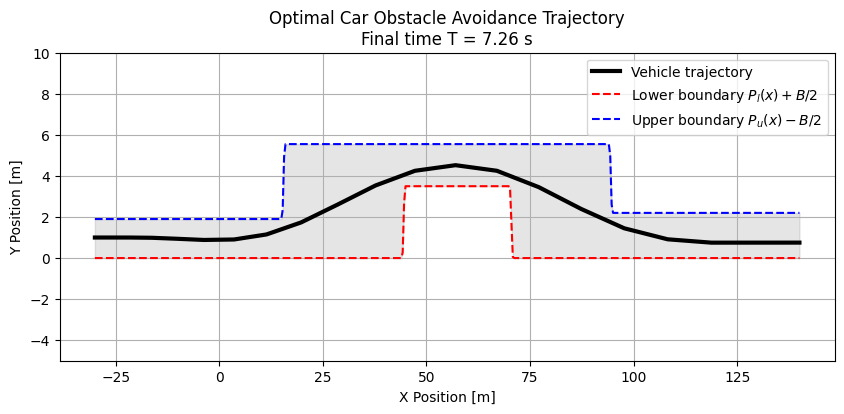

In [20]:
# Solve NLP
solver, nlp, integrator, lbg, ubg, lbw, ubw = setup_ocp(x0, gear, N, solver='ipopt')
solution = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg)
w_opt = solution['x']

# Unpack and visualize solution
X_opt, U_opt, T_opt = unpack_solution(solution['x'], N, integrator, nx=nx, nu=nu)
# print("Solved:", solver.stats()['success'])
print("Final time T_opt:{:.4f}".format(T_opt))
print("Final position X:{:.2f}".format(X_opt[-1, 0]))
print("Final yaw angle Psi:", X_opt[-1, 5])

# Plot the trajectory
plot_trajectory(X_opt, T_opt, track=True, title='Optimal Car Obstacle Avoidance Trajectory')


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.


qpOASES -- An Implementation of the Onl

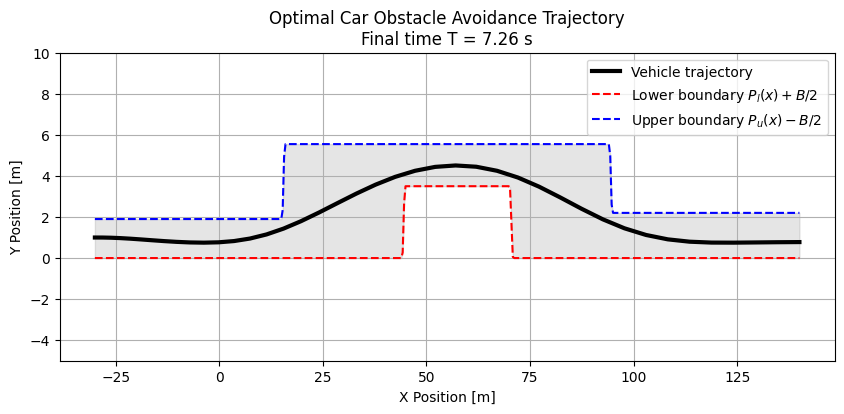

In [21]:
N_new = 40

w0_new = warm_start_from_w(w_opt, N_old=N, N_new=N_new, integrator=integrator, nx=7, nu=3)
solver, _, integrator, lbg_new, ubg_new, lbw_new, ubw_new = setup_ocp(x0, gear, N_new, solver='sqp')
solution = solver(x0=w0_new, lbx=lbw_new, ubx=ubw_new, lbg=lbg_new, ubg=ubg_new)

noise = np.random.normal(0.0, 1.0, size=w0_new.shape)
w0_new = w0_new + noise

# Unpack and visualize solution
X_opt_new, U_opt_new, T_opt_new = unpack_solution(solution['x'], N_new, integrator, nx=nx, nu=nu)
print("Final time T_opt:{:.4f}".format(T_opt_new))
print("Final position X:{:.2f}".format(X_opt_new[-1, 0]))
print("Final yaw angle Psi:", X_opt_new[-1, 5])

# Plot the trajectory
plot_trajectory(X_opt_new, T_opt_new, track=True, title='Optimal Car Obstacle Avoidance Trajectory')

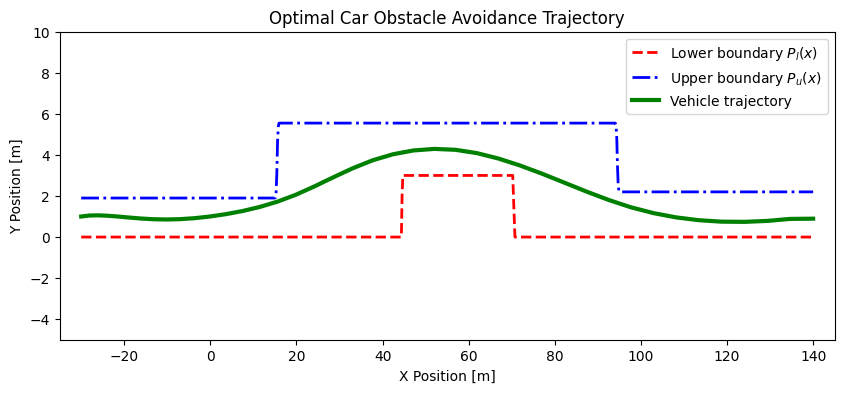

In [24]:
x_car = X_opt_new[:, 0]
y_car = X_opt_new[:, 1]

# 生成用于画边界的等间距 X
x_bound = np.linspace(x_car.min(), x_car.max(), 1000)
# 向量化边界函数
Pl_vec = np.vectorize(Pl_vis)
Pu_vec = np.vectorize(Pu_vis)
lower_bound = Pl_vec(x_bound)
upper_bound = Pu_vec(x_bound)

# ———— 绘图和动画设置 ————
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(x_bound.min() - 5, x_bound.max() + 5)
ax.set_xlabel("X Position [m]")
ax.set_ylabel("Y Position [m]")
ax.set_ylim(-5, 10)
ax.set_title("Optimal Car Obstacle Avoidance Trajectory")

# 先画完整边界
low_line, = ax.plot(x_bound, lower_bound, 'r--', lw=2, label='Lower boundary $P_l(x)$')
up_line, = ax.plot(x_bound, upper_bound, 'b-.', lw=2, label='Upper boundary $P_u(x)$')
# 再初始化车辆轨迹线
traj_line, = ax.plot([], [], color='green', lw=3, label='Vehicle trajectory')
ax.legend(loc='upper right')


def init():
    traj_line.set_data([], [])
    return (traj_line,)


def update(i):
    # 只更新车辆轨迹到第 i 个点
    traj_line.set_data(x_car[:i], y_car[:i])
    return (traj_line,)


anim = FuncAnimation(
    fig,
    update,
    frames=x_car.shape[0] + 1,
    init_func=init,
    interval=50,
    blit=True
)

html_snippet = anim.to_jshtml()
with open("trajectory_anim.html", "w") as f:
    f.write(html_snippet)

# 在 Notebook 查看
HTML(html_snippet)